# 1. Objetivo

Até este momento, a análise exploratória permitiu identificar os principais fatores associados à satisfação dos clientes. Entretanto, todas essas análises possuem caráter descritivo, ou seja, ajudam a entender o que aconteceu após a experiência do cliente.

Nesta etapa, o objetivo é propor uma solução preditiva capaz de estimar a categoria de NPS antes mesmo da aplicação da pesquisa. Com isso, a empresa pode identificar clientes com maior risco de insatisfação e agir preventivamente para reduzir o número de detratores.

## 1.1 Infomações Importantes

- A definição da variável alvo;
- A seleção e preparação das variáveis de entrada;
- A lógica de separação dos dados (quando aplicável);
- A escolha do modelo;
- A forma de avaliação dos resultados;
- E como essa solução poderia ser utilizada na prática pela empresa.

# 2. Preparação dos Dados

## 2.1 Importação das Bibliotecas

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier

## 2.2 Carregamento dos Dados

In [37]:
df_nps = pd.read_csv('../data/desafio_nps_fase_1.csv')

df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2.3 Criação da Variável Alvo

Como o objetivo é prever a categoria do cliente, a nota de NPS foi transformada em três classes, seguindo a metodologia oficial:

Promotor (9 a 10)
Neutro (7 a 8)
Detrator (0 a 6)

In [38]:
def classificar_nps(score):

    if score >= 9:
        return "Promotor"

    elif score >= 7:
        return "Neutro"

    return "Detrator"

df_nps["categoria_nps"] = df_nps["nps_score"].apply(classificar_nps)

In [39]:
df_nps["categoria_nps"].value_counts(normalize=True)*100

categoria_nps
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64

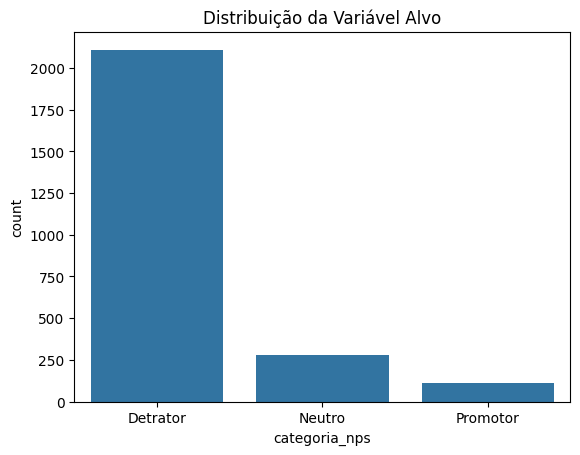

In [40]:
sns.countplot(
    data=df_nps,
    x="categoria_nps",
    order=["Detrator","Neutro","Promotor"]
)

plt.title("Distribuição da Variável Alvo")
plt.show()

Observa-se que a maior parte da base é composta por detratores. Esse desbalanceamento deve ser considerado durante a avaliação do modelo, pois métricas como acurácia podem mascarar o desempenho em classes minoritárias.

# 3. Desenvolvimento do Modelo

## 3.1 Seleção das Variáveis

A seleção das variáveis foi baseada nos resultados obtidos durante a análise exploratória. Foram priorizados indicadores operacionais que apresentaram maior relação com a satisfação do cliente, evitando incluir variáveis sem capacidade explicativa relevante.

In [41]:
features = [

    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
#    'repeat_purchase_30d',
    'delivery_attempts',
    'order_value',
    'items_quantity',
    'customer_tenure_months',
    'freight_value',
    'payment_installments',
    'customer_age'
]

X = df_nps[features]

y = df_nps["categoria_nps"]

In [42]:
X.columns

Index(['delivery_delay_days', 'complaints_count', 'customer_service_contacts',
       'resolution_time_days', 'delivery_attempts', 'order_value',
       'items_quantity', 'customer_tenure_months', 'freight_value',
       'payment_installments', 'customer_age'],
      dtype='object')

Diferentemente da EDA, a variável nps_score não pode ser utilizada como entrada do modelo, pois ela representa exatamente a informação que se deseja prever.

## 3.2 Separação dos Dados em Treino e Teste

Para avaliar a capacidade de generalização do modelo, a base foi dividida em dois subconjuntos:

80% destinados ao treinamento;
20% reservados exclusivamente para teste.

Foi utilizada a opção stratify, garantindo que a proporção entre promotores, neutros e detratores fosse preservada em ambos os conjuntos.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [44]:
print(X_train.shape)
print(X_test.shape)

(2000, 11)
(500, 11)


## 3.3 Treinamento do Modelo

Para esta proposta foi escolhido o algoritmo Random Forest.

Essa técnica possui algumas vantagens importantes para este problema:

- Identifica relações não lineares;
- É robusta a ruídos;
- Lida bem com diferentes escalas de variáveis;
- Fornece a importância de cada variável utilizada na previsão.

Além disso, seu desempenho costuma ser bastante competitivo em bases tabulares como esta.

Nesta etapa o algoritmo aprende padrões existentes entre os indicadores operacionais e a categoria de NPS observada historicamente.

In [45]:
modelo = RandomForestClassifier(

    random_state=42,

    n_estimators=300,

    max_depth=8
)

modelo.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


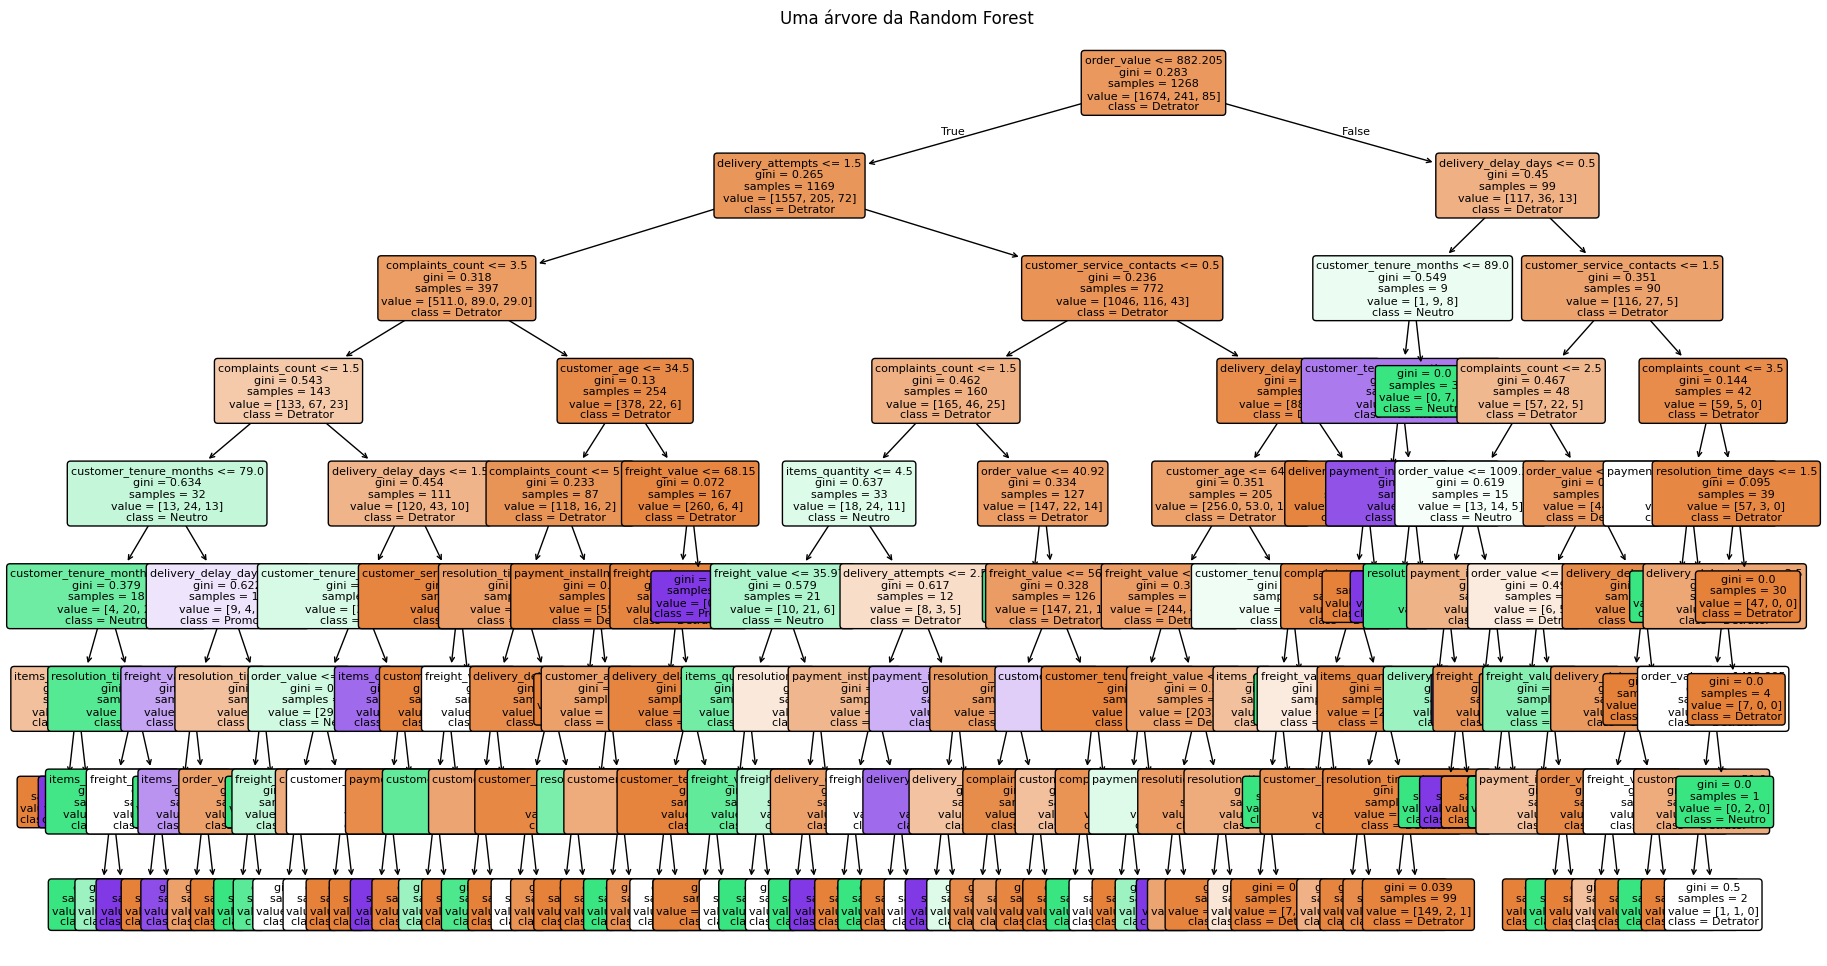

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

plot_tree(
    modelo.estimators_[0],      # primeira árvore
    feature_names=X.columns,
    class_names=modelo.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Uma árvore da Random Forest")
plt.show()

## 3.4 Predição

Após o treinamento, o modelo é aplicado sobre dados que nunca foram vistos anteriormente. Isso permite medir sua capacidade de realizar previsões em novos clientes.

In [47]:
pred = modelo.predict(X_test)

## 3.5 Avaliação do Modelo

In [48]:
print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

    Detrator       0.87      0.99      0.92       422
      Neutro       0.43      0.11      0.17        56
    Promotor       0.50      0.05      0.08        22

    accuracy                           0.85       500
   macro avg       0.60      0.38      0.39       500
weighted avg       0.80      0.85      0.80       500



As métricas de Precision, Recall e F1-Score permitem avaliar o desempenho do modelo para cada categoria individualmente. Neste contexto, o Recall para a classe "Detrator" possui maior relevância para o negócio, pois representa a capacidade do modelo de identificar clientes potencialmente insatisfeitos antes da realização da pesquisa.

A matriz de confusão facilita a interpretação dos acertos e erros do modelo, mostrando quantos clientes de cada categoria foram corretamente classificados e onde ocorreram as principais confusões.

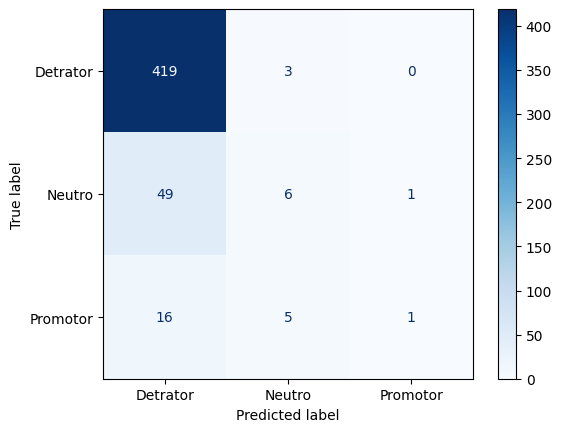

In [49]:
cm = confusion_matrix(
    y_test,
    pred,
    labels=modelo.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot(cmap="Blues")

plt.show()

Idealmente, a maior parte dos valores deve estar concentrada na diagonal principal, indicando elevado número de classificações corretas.

## 3.6 Importação das Variáveis

Um dos principais benefícios da Random Forest é permitir identificar quais variáveis tiveram maior influência nas previsões realizadas.

In [50]:
importancias = pd.DataFrame({

    "Variável": X.columns,

    "Importância": modelo.feature_importances_

})

importancias = importancias.sort_values(
    "Importância",
    ascending=False
)

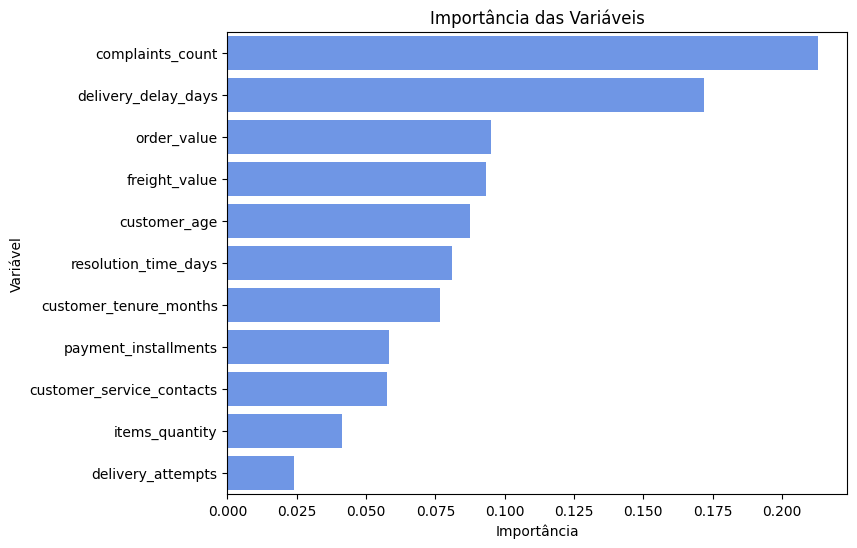

In [51]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=importancias,

    y="Variável",

    x="Importância",

    color="#5B8FF9"

)

plt.title("Importância das Variáveis")

plt.show()

Os resultados confirmam os achados obtidos durante a análise exploratória. Os indicadores ligados ao processo operacional — especialmente atraso na entrega, reclamações e contatos com o atendimento — aparecem entre as variáveis mais importantes para explicar o NPS, reforçando a consistência entre a análise descritiva e o modelo preditivo.

## 3.7 Simulação

Para demonstrar a aplicação prática do modelo, foi criada uma simulação com um cliente fictício que apresenta características frequentemente associadas à insatisfação.

In [64]:
novo_cliente = pd.DataFrame({

'delivery_delay_days':[5],

'complaints_count':[4],

'customer_service_contacts':[3],

'resolution_time_days':[5],

#'repeat_purchase_30d':[0],

'delivery_attempts':[2],

'order_value':[250],

'items_quantity':[3],

'customer_tenure_months':[10],

'freight_value':[20],

'payment_installments':[6],

'customer_age':[35]

})

In [65]:
modelo.predict(novo_cliente)

array(['Detrator'], dtype=object)

In [66]:
probs = pd.DataFrame(
    modelo.predict_proba(novo_cliente),
    columns=modelo.classes_
)

probs = (probs * 100).round(2)

probs

,Detrator,Neutro,Promotor
0,96.77,3.07,0.16


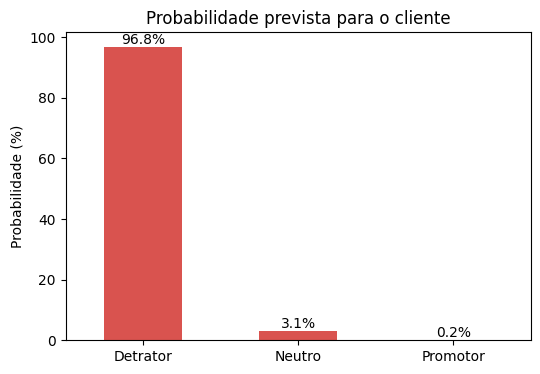

In [67]:
probs.T.plot(
    kind='bar',
    legend=False,
    color=['#D9534F', '#F0AD4E', '#5CB85C'],
    figsize=(6,4)
)

plt.title("Probabilidade prevista para o cliente")
plt.ylabel("Probabilidade (%)")
plt.xticks(rotation=0)

for i, v in enumerate(probs.iloc[0]):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.show()

O modelo atribuiu aproximadamente 96,8% de probabilidade de este cliente ser classificado como detrator. Em um cenário real, essa informação poderia acionar automaticamente um fluxo de atendimento preventivo antes mesmo da aplicação da pesquisa de NPS.

**Exemplo de aplicação do modelo**: Considerando um cliente com 5 dias de atraso na entrega, 4 reclamações registradas, 3 contatos com o atendimento e ausência de recompra, o modelo estimou uma probabilidade de 96,8% de que esse cliente seja um detrator. Esse tipo de previsão permitiria à empresa identificar clientes de alto risco antes mesmo da aplicação da pesquisa de NPS, possibilitando ações preventivas, como priorização da resolução do problema, contato proativo do atendimento ou oferta de compensações para reduzir a chance de uma experiência negativa.

A implementação desse modelo permitiria transformar um processo atualmente reativo em uma estratégia preditiva. Em vez de descobrir a insatisfação apenas após o envio da pesquisa de NPS, a empresa passaria a identificar clientes de maior risco em tempo real, direcionando ações preventivas como priorização logística, contato proativo, resolução antecipada de problemas ou concessão de benefícios. Dessa forma, o modelo deixa de ser apenas uma ferramenta estatística e passa a apoiar diretamente a tomada de decisão operacional.